<div style='color: #216969;
           background-color: #EAF6F6;
           font-size: 200%;
           border-radius:15px;
           text-align:center;
           font-weight:600;
           border-style: solid;
           border-color: dark green;
           font-family: "Cambria";'>
Confusion Matrix ....
<a class="anchor" id="1"></a> 

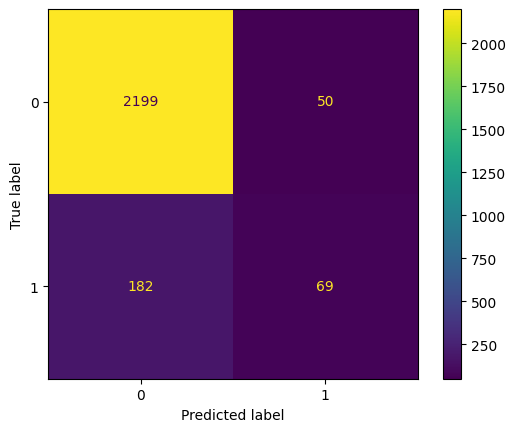

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay


X, y = make_classification(n_samples=10_000, weights=[0.9, 0.1], random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

model  = LogisticRegression(C=1e6, random_state=0).fit(X_train, y_train)
_ = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

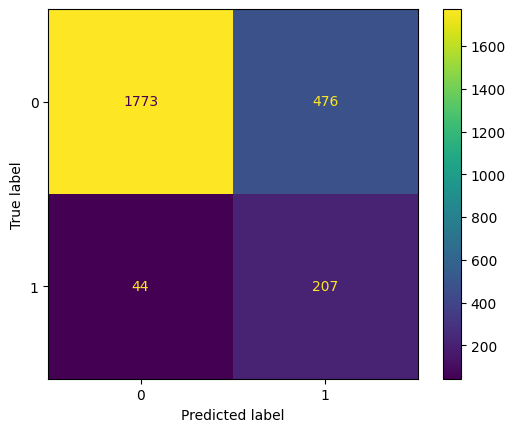

In [3]:
from sklearn.model_selection import FixedThresholdClassifier

model = FixedThresholdClassifier(model, threshold=0.1)
model.fit(X_train, y_train)
_ = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [5]:
from sklearn.metrics import confusion_matrix


def custom_score(y_observed, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_observed, y_pred, normalize="all").ravel()
    return tp - 2 * fn - 0.1 * fp


print("Untuned decision threshold: 0.5")
print(f"Custom score: {custom_score(y_test, model.predict(X_test)):.2f}")

Untuned decision threshold: 0.5
Custom score: 0.03


In [6]:
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import make_scorer

custom_scorer = make_scorer(
    custom_score, response_method="predict", greater_is_better=True
)
tuned_classifier = TunedThresholdClassifierCV(
    model, cv=5, scoring=custom_scorer
).fit(X, y)

print(f"Tuned decision threshold: {tuned_classifier.best_threshold_:.3f}")
print(f"Custom score: {custom_score(y_test, tuned_classifier.predict(X_test)):.2f}")

Tuned decision threshold: 0.071
Custom score: 0.04
